# N=100, u=320 quick crossover-cap screen

## Mandatory contract for users and AI agents

**This notebook follows `scripts/templates/boilerplate_run.ipynb`, the source of truth for run notebooks.** Keep its cell order, headings, guards, and adapter calls. Do not add, remove, reorder, merge, or redesign sections without the user's explicit permission in the current conversation.

This isolates the cap change by reusing the u=160 smoothness, sharpness, and Adam-family settings at u=320. It performs 250 broad Fourier starts for 10,000 exploratory Adam steps, applies 500 monotone peak-refinement steps to every result, and refines the top 20 with L-BFGS-B until loose stability or a 30-minute timeout. It deliberately stops after loose refinement. Every handoff preserves controls and explicitly resets optimizer state.

In [1]:
from ofc.notebook_workflow import RunNotebook
from ofc.seed_sensitivity import fixed_cap_seed_sensitivity_documents

run_name = "N100_u320_quick_crossover_screen_gpu"
workflow = RunNotebook(run_name)

## Create the immutable configs

Edit the exposed arguments, then activate once. `resume_optimizer=False` deliberately restores controls with a fresh optimizer state at each stage boundary. Only the exploration, all-run polish, and top-20 loose configs are created.

In [2]:
Activated = False

reuse_existing = False
database = "results/bar_u320_crossover_screen.sqlite3"
resolutions = [100]
cap_settings = {
    320: {"adam_learning_rate": 0.05, "adam_beta1": 0.95, "adam_beta2": 0.99, "smoothness": 1.25e-7, "sharpness": 1.25e-8},
}
exploration_initialisations = 250
exploration_schedule = [(2_500, 1.5), (7_500, 0.75)]
all_polish_steps = 500
top_count = 20
batch_sizes = {100: 25}
loose_max_elapsed_seconds = 30 * 60
strict_max_elapsed_seconds = 30 * 60
fourier_num_modes = 6
fourier_rms_amplitude = 0.8
fourier_intensity_fraction = 0.5
resume_optimizer = False

all_documents = fixed_cap_seed_sensitivity_documents(
    cap_settings=cap_settings, resolutions=resolutions, database=database,
    exploration_initialisations=exploration_initialisations, exploration_schedule=exploration_schedule,
    all_polish_steps=all_polish_steps, batch_sizes=batch_sizes, top_count=top_count,
    loose_max_elapsed_seconds=loose_max_elapsed_seconds, strict_max_elapsed_seconds=strict_max_elapsed_seconds,
    fourier_num_modes=fourier_num_modes, fourier_rms_amplitude=fourier_rms_amplitude,
    fourier_intensity_fraction=fourier_intensity_fraction, resume_optimizer=resume_optimizer,
)
pipeline_documents = all_documents[:3]
pipeline_workflows = workflow.create_config_group(
    activated=Activated, documents=pipeline_documents, reuse_existing=reuse_existing,
)

Grouped config creation is disabled (Activated=False); found 3/3 existing configs.


## Run directly on `bar`'s GPU (detached)

This verifies JAX CUDA visibility and launches the three immutable configs in dependency order inside one detached process. `--continue-on-error` records a failed stage and still attempts the next queued config.

In [3]:
Activated = False

queue_id = None
python_executable = "/home/gyqyan/charlie/.conda/envs/optical-feshbach-control/bin/python"
extra_arguments = ["--continue-on-error"]
detached = True
log_path = "logs/N100_u320_quick_crossover_screen_gpu.log"

active_queue_id = pipeline_workflows[0].run_on_bar_gpu_group(
    activated=Activated, additional_workflows=pipeline_workflows[1:],
    queue_id=queue_id, python_executable=python_executable, extra_arguments=extra_arguments,
    detached=detached, log_path=log_path,
)

Grouped bar GPU execution is disabled (Activated=False).


## Submit through Slurm (alternative)

The requested screen is a bar-GPU run. Leave this alternative inactive unless the execution method is explicitly changed.

In [4]:
Activated = False

partition = "zen5,epyc"
time = "04:00:00"
cpus = 4
memory = "16G"
array = False
array_max_concurrent = None
job_name = None
extra_arguments = []

active_queue_id = pipeline_workflows[0].submit_slurm(
    activated=Activated, partition=partition, time=time, cpus=cpus, memory=memory,
    array=array, array_max_concurrent=array_max_concurrent, job_name=job_name,
    extra_arguments=extra_arguments,
)

Slurm submission is disabled (Activated=False).


## Query persisted data

Choose one created stage: exploration=0, all-run polish=1, or top-20 loose=2. The default shows all loosely refined finalists.

In [5]:
stage_offset = 2  # 0=exploration, 1=all polish, 2=top-20 loose.
query_workflows = [pipeline_workflows[stage_offset]]
queue_id = None
config_run_rank = 1
statuses = None
filters = {"u_max": 320}
sweep_parameters = ["initialization_index"]
require_saved_stage = True
allow_missing = True
limit = None
order_by = "run_id"
descending = False

query_result = query_workflows[0].query_group(
    additional_workflows=query_workflows[1:], queue_id=queue_id,
    config_run_rank=config_run_rank, statuses=statuses, filters=filters,
    sweep_parameters=sweep_parameters, require_saved_stage=require_saved_stage,
    allow_missing=allow_missing, limit=limit, order_by=order_by, descending=descending,
)

{'config_name': 'N100_u320_fixed_parameter_seed250_top20_loose_gpu',
 'config_id': 342174085716552340,
 'queue_id': 2929830628051672910,
 'execution_status': 'complete',
 'registered_runs': 20,
 'queried_runs': 20,
 'run_statuses': {'complete': 20},
 'varying_parameters': ('initialization_index',),
 'selected_sweeps': (),
 'query_source': 'local config',
 'database': 'results/bar_u320_crossover_screen.sqlite3'}

{'config_names': ('N100_u320_fixed_parameter_seed250_top20_loose_gpu',),
 'queue_id': 2929830628051672910,
 'registered_runs': 20,
 'queried_runs': 20,
 'varying_parameters': ('initialization_index',),
 'selected_sweeps': ('initialization_index',),
 'not_started_or_unsaved': (),
 'database': '/home/gyqyan/charlie/optical-feshbach-control/results/bar_u320_crossover_screen.sqlite3'}

## Figure display and saving

In [6]:
save_figure = None
figure_format = "png"
preview_dpi = 240
save_dpi = 600

## Unified sweep summary

The history median/spread and objective strip use only the runs selected above. Dashed vertical lines mark the actual learning-rate changes.

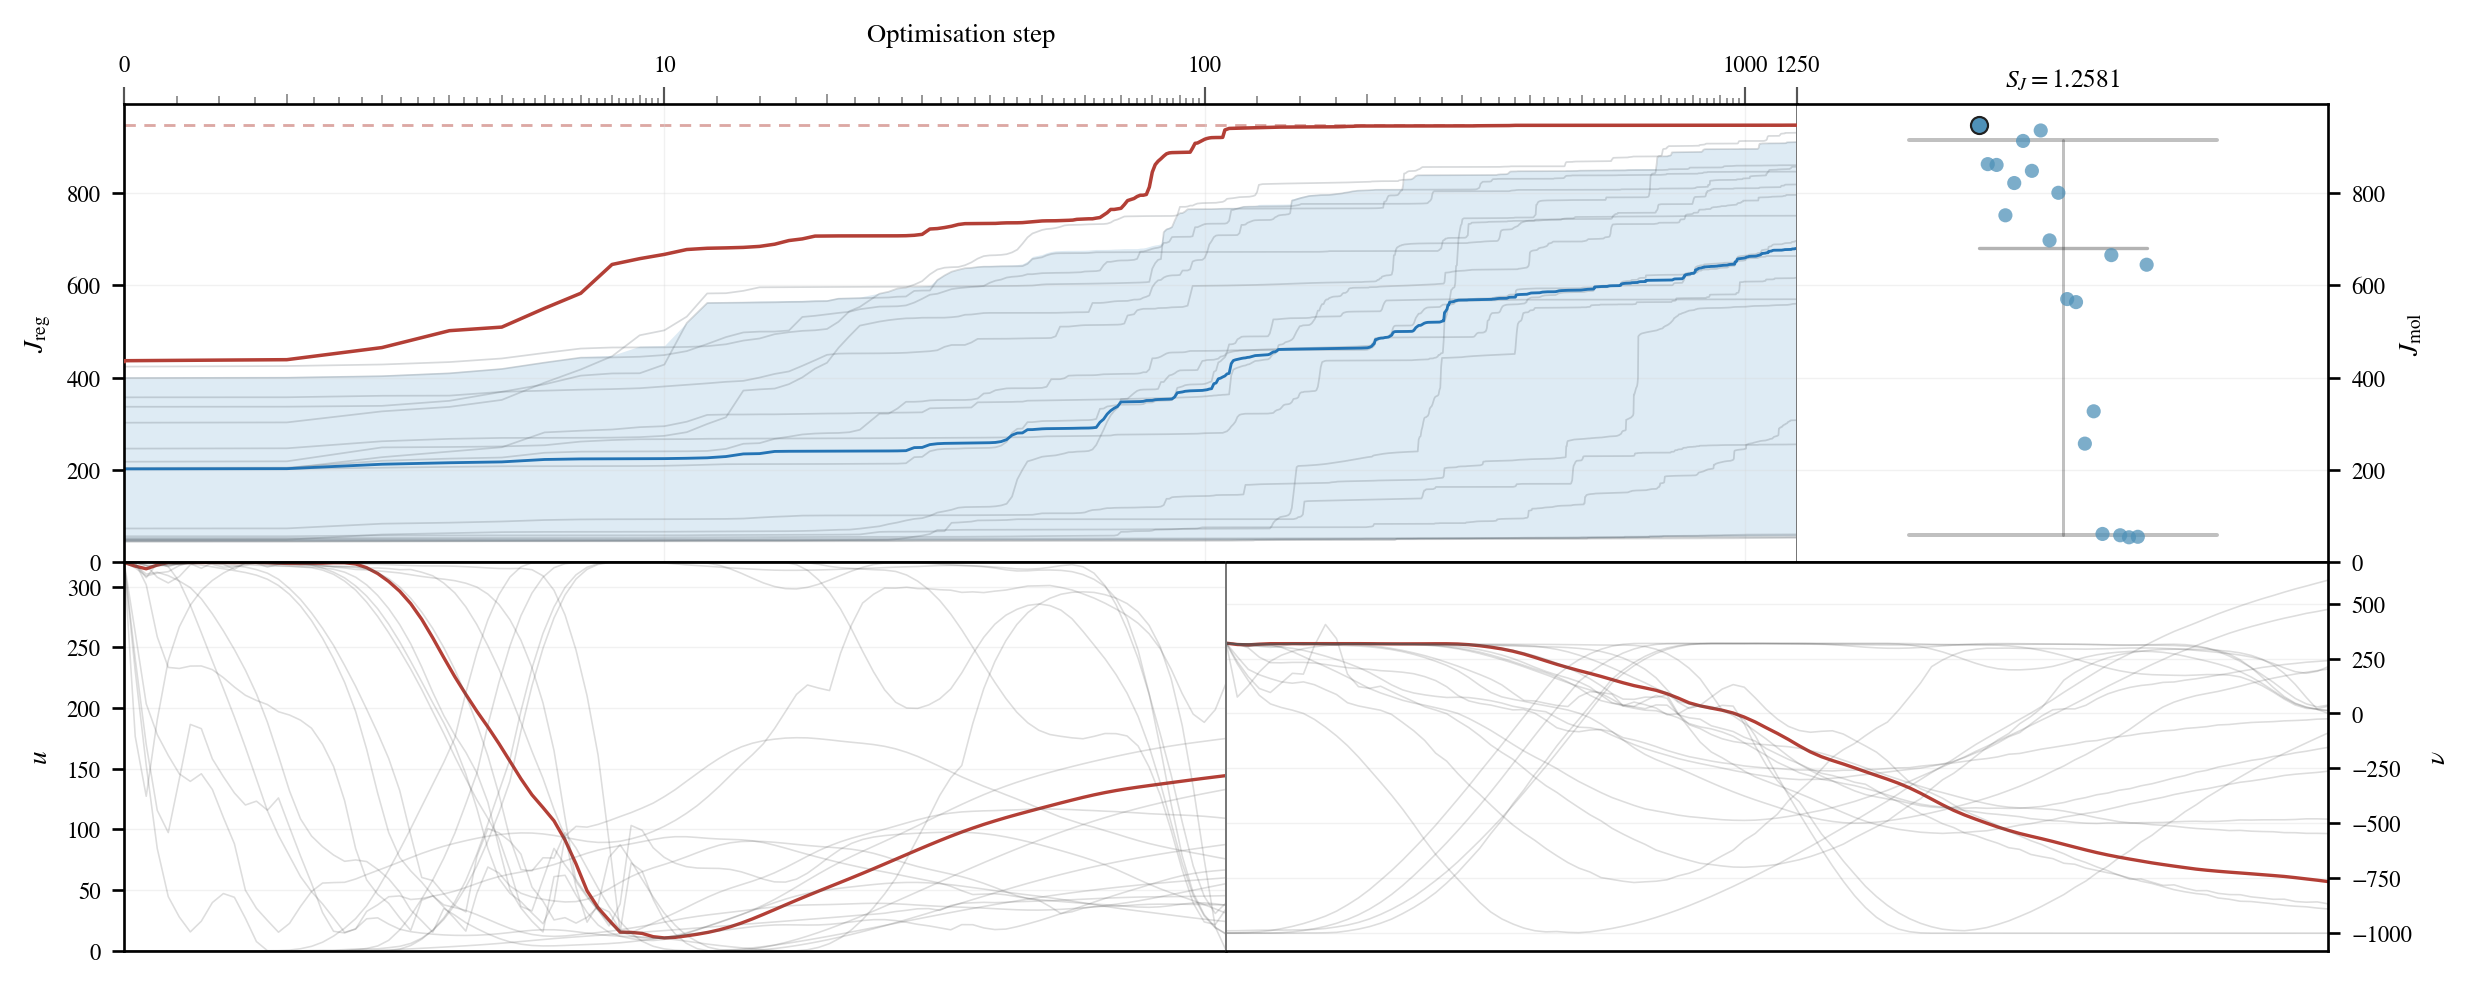

In [7]:
sweep_parameter = "initialization_index"
history_points = 1200
summary_figure = query_result.plot_summary(sweep_parameter=sweep_parameter, history_points=history_points)
workflow.present_figure(summary_figure, "01_sweep_summary", save_figure=save_figure, figure_format=figure_format, preview_dpi=preview_dpi, save_dpi=save_dpi)

## Double sweep summary

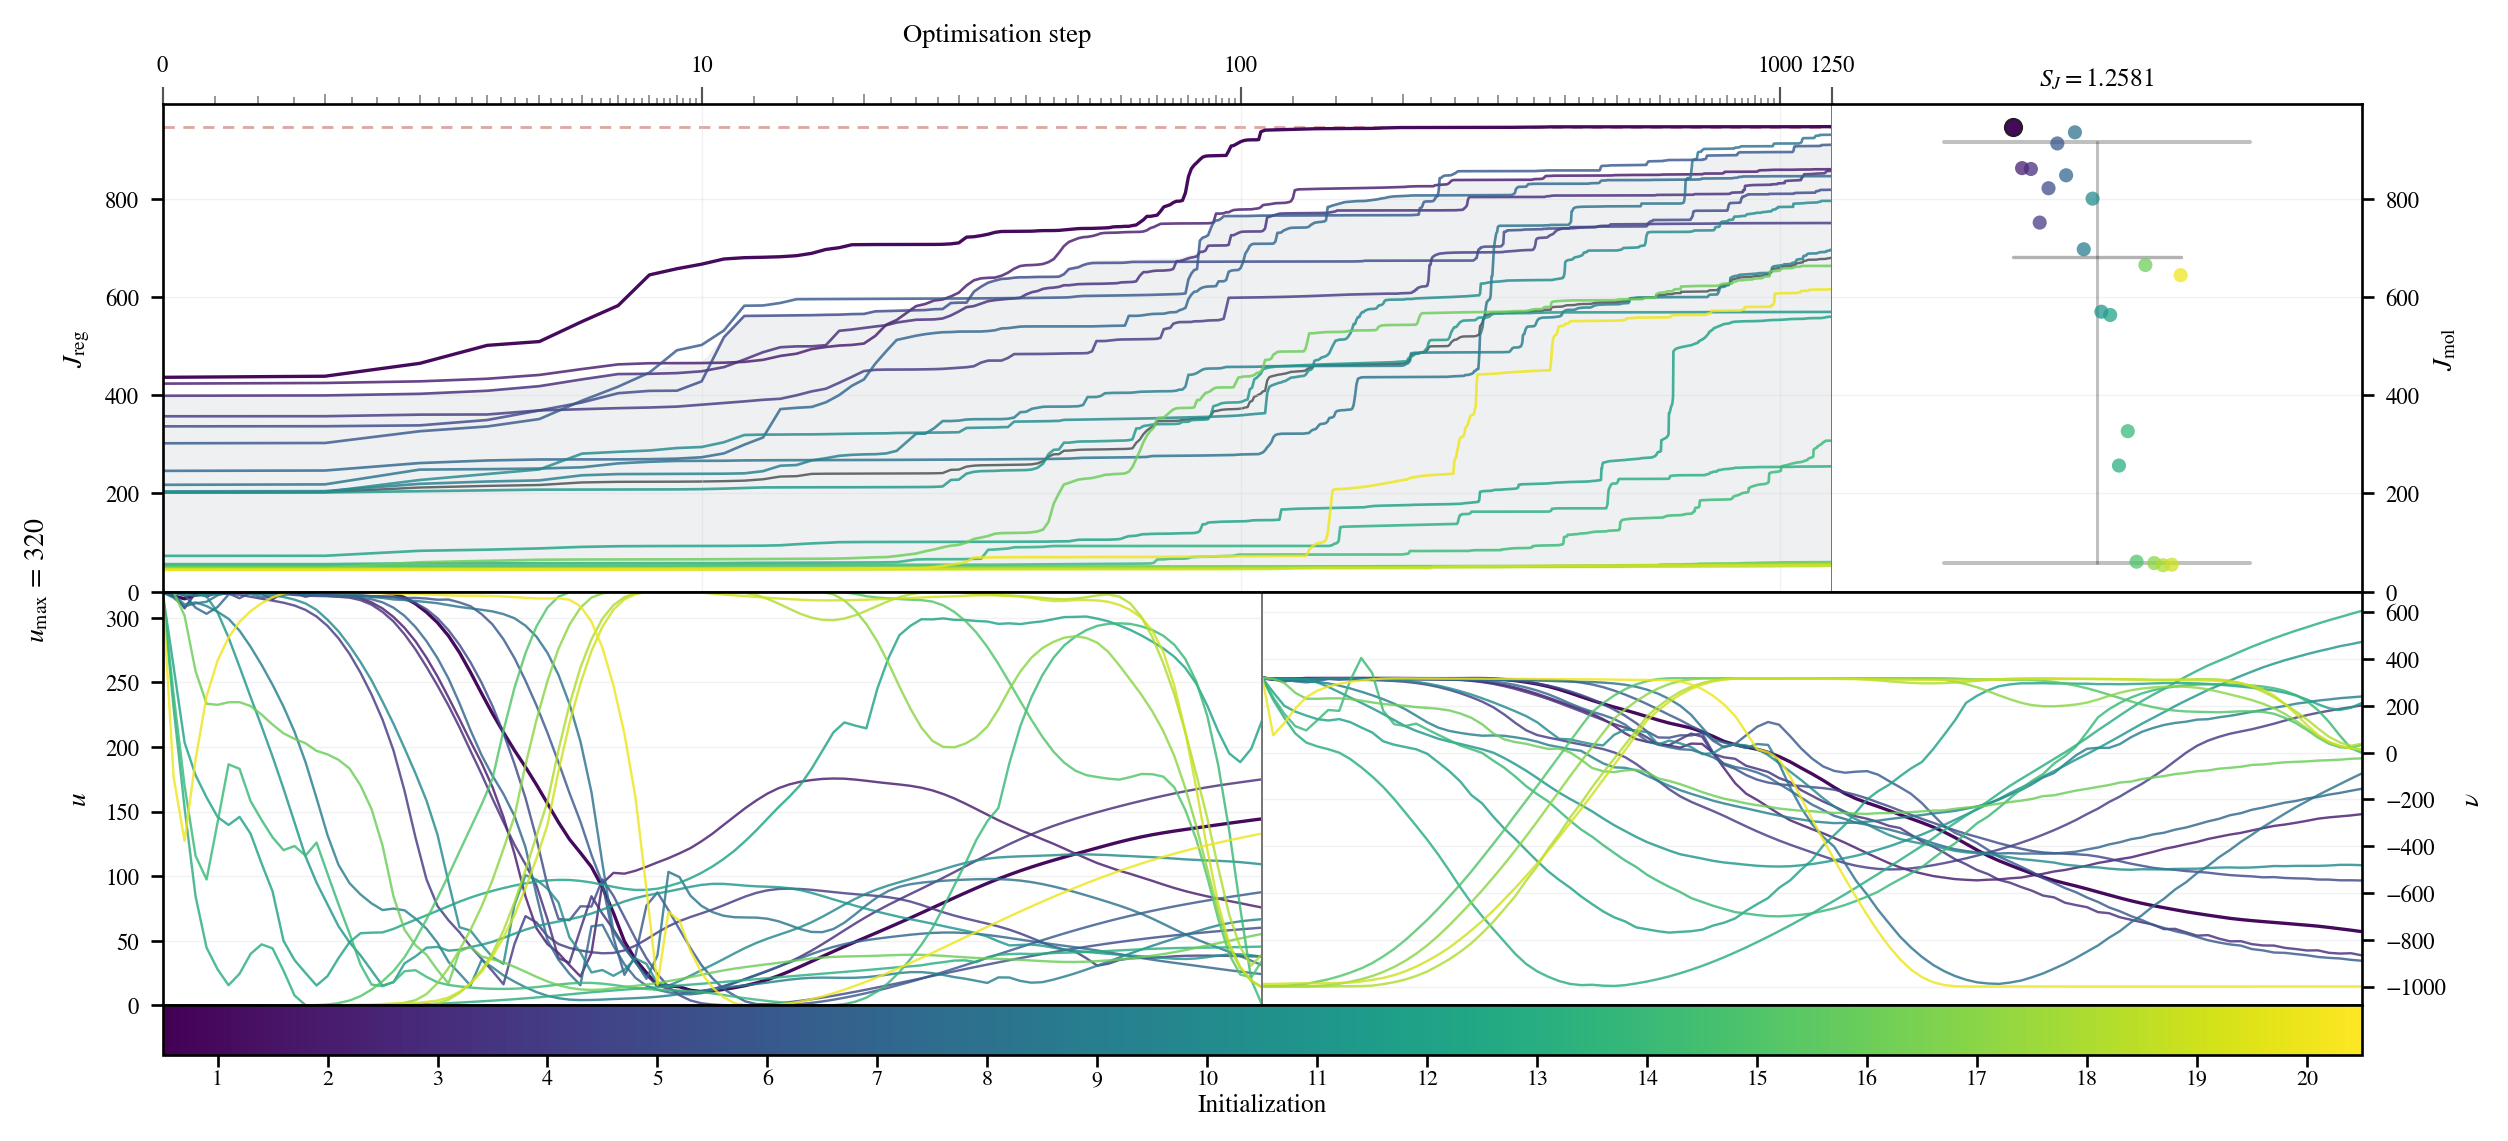

In [8]:
separate_sweep_parameter = "u_max"
colour_sweep_parameter = "initialization_index"
history_points = 1200
double_sweep_figure = query_result.plot_double_sweep_summary(separate_sweep_parameter=separate_sweep_parameter, colour_sweep_parameter=colour_sweep_parameter, history_points=history_points)
workflow.present_figure(double_sweep_figure, "02_double_sweep_summary", save_figure=save_figure, figure_format=figure_format, preview_dpi=preview_dpi, save_dpi=save_dpi)

## Triple sweep summary

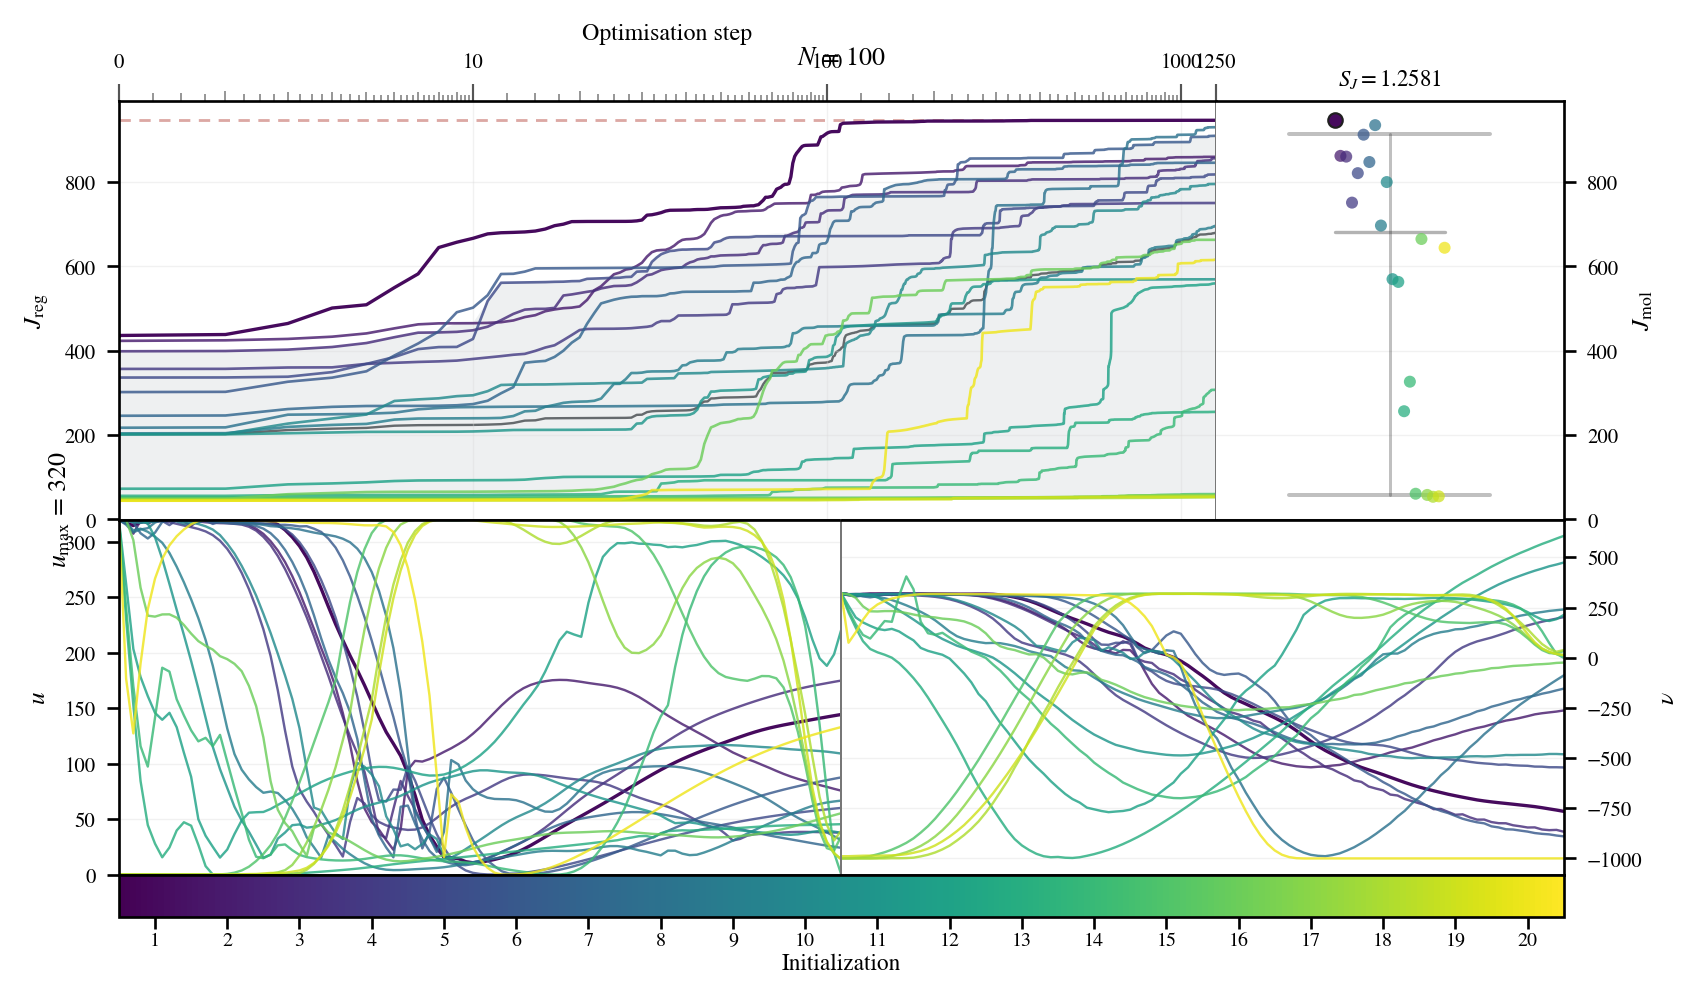

In [9]:
row_sweep_parameter = "u_max"
column_sweep_parameter = "N"
colour_sweep_parameter = "initialization_index"
history_points = 1200
triple_sweep_figure = query_result.plot_triple_sweep_summary(row_sweep_parameter=row_sweep_parameter, column_sweep_parameter=column_sweep_parameter, colour_sweep_parameter=colour_sweep_parameter, history_points=history_points)
workflow.present_figure(triple_sweep_figure, "03_triple_sweep_summary", save_figure=save_figure, figure_format=figure_format, preview_dpi=preview_dpi, save_dpi=save_dpi)